### Imports essential libraries for machine learning, numerical computation, plotting, and managing data structures. 
### These are foundational for building a reinforcement learning model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import math
import numpy as np
import random
import time

from collections import deque, namedtuple
from itertools import count

from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

## Local Runtime Configuration - Indicates if the code is running on a local machine. This can be used to manage paths or settings differently for local vs. remote runs.

In [2]:
local_runtime = True

## Set Local Path - Sets the path for saving models or data files if running locally.


In [3]:
if local_runtime:
    path = "C:/Users/patha/2048/"

## Device Selection : Determines whether to use GPU (cuda) or CPU for computations, depending on hardware availability.

In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Speed up Computations : Optimizes convolution operations for faster training on GPUs.

In [5]:
torch.backends.cudnn.benchmark = True

In [6]:

device
     

device(type='cuda', index=0)

## Environment Abstract Class - A template for creating environments. It defines essential methods like reset, step, state, and utilities like checking if the game is over.




In [7]:
class Env(ABC):

    @abstractmethod
    def __init__(self):
        pass

    @abstractmethod
    def reset(self):
        pass

    @abstractmethod
    def step(self, action):
        pass
    
    @abstractmethod
    def score(self):
        pass
    
    @abstractmethod
    def state(self):
        pass

    # returns if the game is over
    def is_done(self):
        if self.empty_tiles() > 0:
            return False
        grid = self.state()
        for i in range(4):
            for j in range(4):
                if  i != 0 and grid[i-1][j] == grid[i][j] or \
                    j != 0 and grid[i][j-1] == grid[i][j]:
                    return False
        return True

    def max_tile(self):
        return 1 << self.state().max()    

    def _can_perform(self, action):
        tmp = np.rot90(self.state(), action)
        for i in range(4):
            empty = False
            for j in range(4):
                empty |= tmp[i, j] == 0
                if tmp[i, j] != 0 and empty:
                    return True
                if j > 0 and tmp[i, j] != 0 and tmp[i, j] == tmp[i, j-1]:
                    return True
        return False
    
    def possible_actions(self):
        res = []
        for action in range(4):
            if self._can_perform(action):
                res.append(action)
        return res

    def empty_tiles(self):
        grid = self.state()
        count = 0
        for i in range(4):
            for j in range(4):
                count += (grid[i, j] == 0)
        return count

## 2048 Environment Implementation : Implements the 2048 game logic, including resetting the game, adding tiles, scoring, and rendering the grid.

In [9]:
class Env2048(Env):

	def __init__(self):
		super().__init__()
		self.grid = np.zeros((4, 4), dtype=int)
		self.add_tile()
		self.add_tile()
		self._score = 0

	def reset(self):
		self.__init__()
		return self.grid

	def add_tile(self):
		# add a new tile (2/4) in a random empty place
		i, j = (self.grid == 0).nonzero()
		rnd = np.random.choice(len(i))
		self.grid[i[rnd], j[rnd]] = np.random.choice([1, 2], p=[0.9, 0.1])

	def step(self, action):
		# rotate the board and step left
		rotated_board = np.rot90(self.grid, action)
		next_state = np.zeros((4, 4), dtype=int)

		# try to merge tiles in each column
		for col_idx in range(4):
			col = rotated_board[col_idx, :]
			result = np.zeros(4, dtype=col.dtype)
			j, prev = 0, None
			for i in range(4):
				if col[i] != 0:
					# move tile to next empty place
					if prev is None:
						prev = col[i]
					# merge tiles
					elif prev == col[i]:
						result[j] = col[i] + 1
						self._score += 1 << result[j]
						j += 1
						prev = None
					else:
						result[j] = prev
						j += 1
						prev = col[i]
			if prev is not None:
				result[j] = prev
			next_state[col_idx] = result

		# rotate back and return to original state
		next_state = np.rot90(next_state, -action)
		if not (next_state == self.grid).all():
			self.grid = next_state
			self.add_tile()

		# returns the reward - #empty tiles
		return self.empty_tiles()

	def score(self):
		return self._score

	def state(self):
		return self.grid

	def render(self):
		print('-'*25)
		for i in range(4):
			for j in range(4):
				print((1 << self.grid[i][j] if self.grid[i][j] != 0 else "0"), end="\t")
			print()
		print('-'*25)

## Transition Tuple Represents a single experience in the replay memory, with state, next state, action, reward, and whether the episode is done.

In [10]:
Transition = namedtuple('Transition', ('state', 'next_state', 'action', 'reward', 'done'))

## Replay Memory : Stores past experiences for experience replay in Deep Q-Network (DQN) training.

In [11]:
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

## DQN Model -- Defines the neural network used for Q-value approximation. Includes convolutional layers to process the game state and fully connected layers for Q-value outputs.

### Double Q-Network (DQN)

The **DQN** is a neural network used to approximate Q-values for reinforcement learning tasks.
   - Takes the game state (one-hot encoded 4x4 grid) as input.
   - Outputs Q-values for each possible action (`Left`, `Up`, `Right`, `Down`).
   - **Convolutional Layers**: Extract spatial features from the board.
   - **Fully Connected Layers**: Combine features to compute Q-values.
   - Final output: A vector of 4 Q-values (one per action).
   - Input passes through convolutional layers, then is flattened and concatenated.
   - Fully connected layers process this into Q-values.
   - `policy_net`: Chooses actions based on Q-values.
   - `target_net`: Provides stable Q-values for training.

This setup allows the agent to learn optimal actions for maximizing game rewards.


1.Input: 4x4 One-Hot Encoded Grid (16 Channels)

2.Convolutional Layer 1

3.Convolutional Layer 2
      
4.Flatten + Concatenate Features
      
5.Fully Connected Layer 1 (256 Neurons, ReLU Activation)
      
6.Fully Connected Layer 2 (4 Outputs - Q-values for [Left, Up, Right, Down])


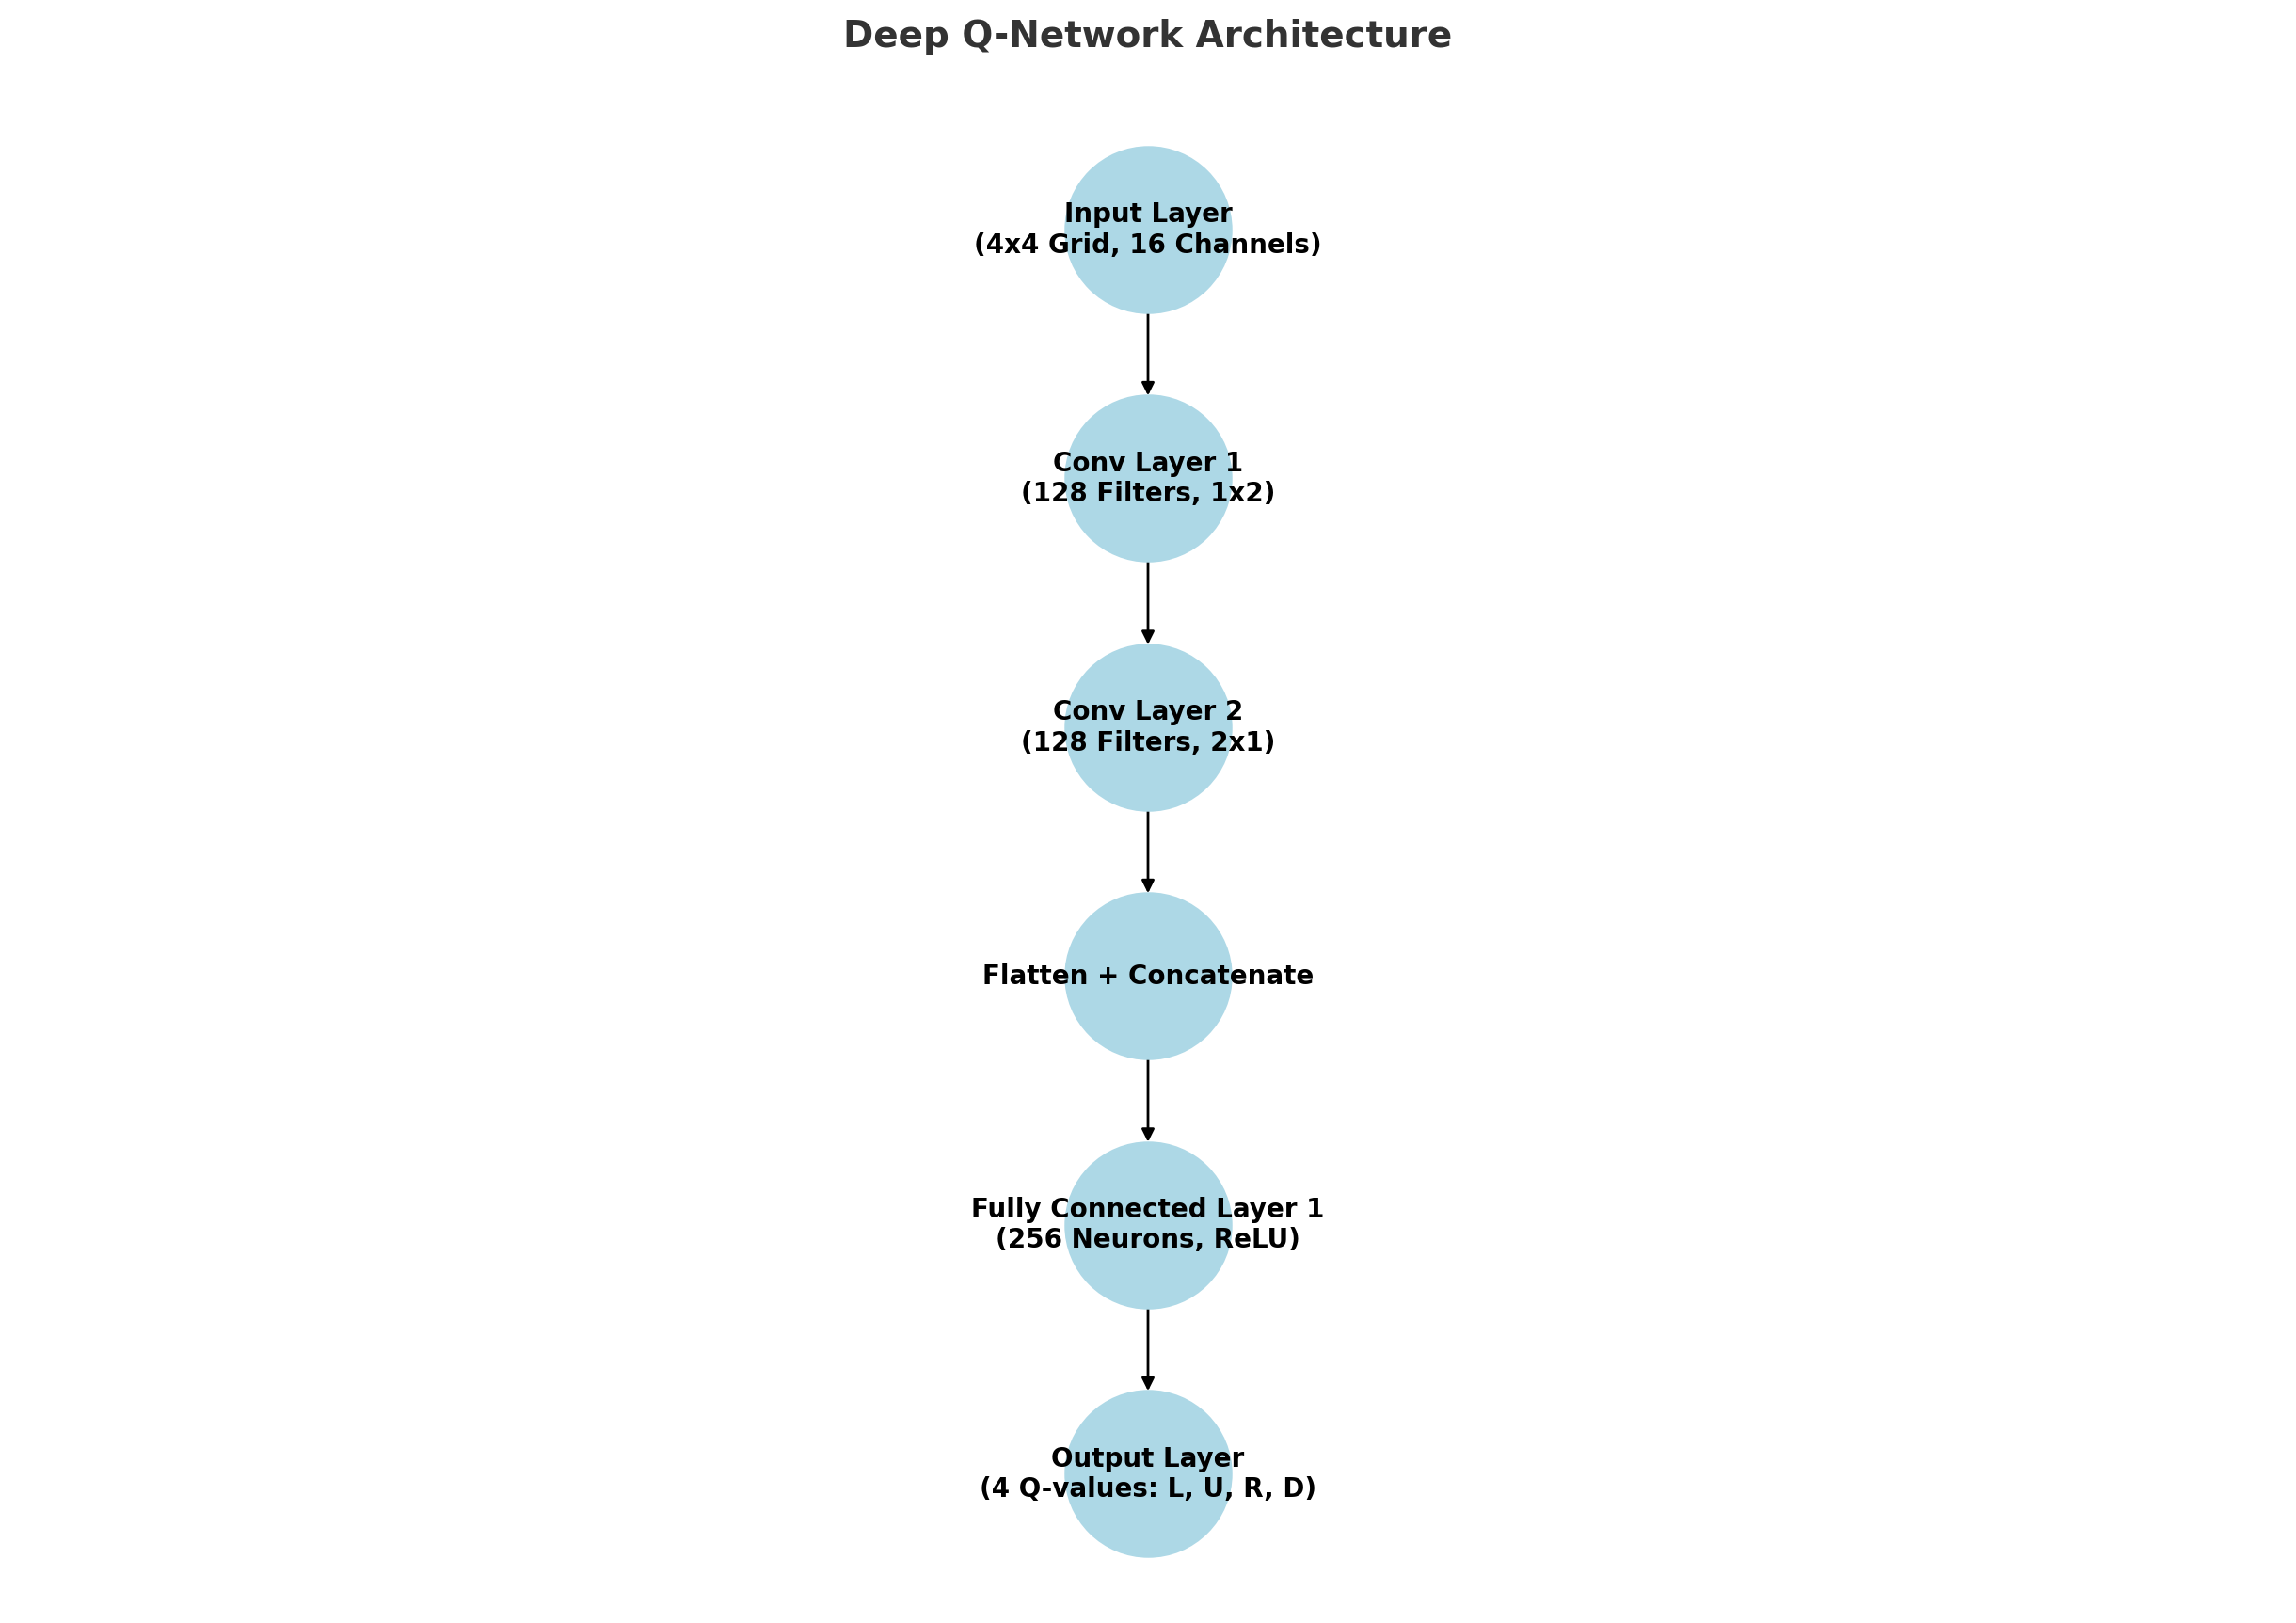

In [49]:
from IPython.display import Image, display

# Display the image
display(Image(filename='output (15).png'))

In [12]:
class DQN(nn.Module):

    def __init__(self):
        super(DQN, self).__init__()

        self.conv1 = nn.Conv2d(16, 128, kernel_size=(1,2))
        self.conv2 = nn.Conv2d(16, 128, kernel_size=(2,1))

        self.conv11 = nn.Conv2d(128, 128, kernel_size=(1,2))
        self.conv12 = nn.Conv2d(128, 128, kernel_size=(2,1))
        self.conv21 = nn.Conv2d(128, 128, kernel_size=(1,2))
        self.conv22 = nn.Conv2d(128, 128, kernel_size=(2,1))
        
        first_layer = 4*3*128*2
        second_layer = 2*4*128*2 + 3*3*128*2
        self.fc = nn.Sequential(
            nn.Linear(first_layer + second_layer, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        x = x.to(device)
        x1 = F.relu(self.conv1(x))
        x2 = F.relu(self.conv2(x))
        
        x11 = F.relu(self.conv11(x1))
        x12 = F.relu(self.conv12(x1))
        x21 = F.relu(self.conv21(x2))
        x22 = F.relu(self.conv22(x2))
        
        s1 = x1.shape
        s2 = x1.shape
        
        s11 = x11.shape
        s12 = x12.shape
        s21 = x21.shape
        s22 = x22.shape
        
        x1 = x1.view(s1[0], s1[1]*s1[2]*s1[3])
        x2 = x2.view(s2[0], s2[1]*s2[2]*s2[3])

        x11 = x11.view(s11[0], s11[1]*s11[2]*s11[3])
        x12 = x12.view(s12[0], s12[1]*s12[2]*s12[3])
        x21 = x21.view(s21[0], s21[1]*s21[2]*s21[3])
        x22 = x22.view(s22[0], s22[1]*s22[2]*s22[3])
        
        concat = torch.cat((x1,x2,x11,x12,x21,x22), dim=1)
        return self.fc(concat)

## Hyperparameters - Configures training parameters like batch size, discount factor, epsilon for exploration, and learning rate.

In [14]:
# hyperparameters
BATCH_SIZE = 128      # batch size sampled from memory
GAMMA = 0.99          # discount rate
EPS_START = 0.1       # initial epsilon
EPS_END = 0.0001      # final epsilon
BUFFER_SIZE = 50000   # replay memory size
UPDATE_RATE = 10      # rate of policy updates to target
LEARNING_RATE = 1e-4  # learning rate alpha
DECAY = 10000         # epsilon decay

## Policy and Target Networks - Initializes the two neural networks: policy_net for selecting actions and target_net for stable Q-value updates.

In [15]:
policy_net = DQN().to(device)
target_net = DQN().to(device)
target_net.load_state_dict(policy_net.state_dict())

<All keys matched successfully>

## Replay Memory Initialization - Sets up the replay memory and optimizer for training.


In [16]:
memory = ReplayMemory(BUFFER_SIZE)
optimizer = torch.optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
steps_done = 0

In [17]:
epsilon = EPS_START

In [18]:
episode_durations = []
scores = []
max_tiles = []

## One-hot encoding - Converts the game state grid into a one-hot encoded format for input into the DQN.

In [19]:
def one_hot_encode(state):
    result = np.zeros((1, 16, 4, 4), dtype=np.float32)
    for i in range(4):
        for j in range(4):
            result[0][state[i][j]][i][j] = 1.0
    return result

## Action Selection (Epsilon-Greedy) - Chooses an action based on exploration or exploitation.




In [20]:
def select_action(state, possible_actions, train=True):
    global epsilon
    state = torch.from_numpy(state).to(device)
    if random.random() < epsilon and train:
        return np.random.choice(possible_actions)
    actions = policy_net(state).argsort()[0].cpu().numpy()[::-1]
    for action in actions:
        if action in possible_actions:
            return action
    raise ValueError()
     

## Model Optimization - Updates the policy network using samples from the replay memory.

In [21]:
def optimize_model():
    global steps_done, epsilon
    if len(memory) < BATCH_SIZE:
        return
    steps_done += 1
    if steps_done % UPDATE_RATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    batch_state, batch_next_state, batch_action, batch_reward, batch_done = zip(*memory.sample(BATCH_SIZE))
	
    batch_state = torch.FloatTensor(np.array(batch_state)).squeeze(1).to(device)
    batch_next_state = torch.FloatTensor(np.array(batch_next_state)).squeeze(1).to(device)
    batch_action = torch.Tensor(batch_action).unsqueeze(1).to(device)
    batch_reward = torch.Tensor(batch_reward).unsqueeze(1).to(device)
    batch_done = torch.FloatTensor(batch_done).unsqueeze(1).to(device)

    with torch.no_grad():
        next_q_vals = target_net(batch_next_state)
        y = batch_reward + (1 - batch_done) * GAMMA * torch.max(next_q_vals, dim=1, keepdim=True)[0]
    
    loss = F.mse_loss(policy_net(batch_state).gather(1, batch_action.long()), y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epsilon > EPS_END:
        epsilon -= (EPS_START - EPS_END) / DECAY

## Training Function - Manages the training loop, including resetting the environment, selecting actions, storing experiences, and optimizing the model.

In [22]:
def train(env: Env, episodes=3000, save_rate=100, print_rate=100):
    global steps_done, epsilon
    start_time = time.time()
    for episode in range(episodes):
        state = one_hot_encode(env.reset())
        for t in count():
            action = select_action(state, env.possible_actions())
            reward = env.step(action)
            next_state = one_hot_encode(env.state())
            done = env.is_done()

            memory.push(state, next_state, torch.FloatTensor([[action]]).to(device), torch.FloatTensor([[reward]]).to(device), torch.FloatTensor([[done]]).to(device))
            optimize_model()

            state = next_state
            if done:
                episode_durations.append(t + 1)
                scores.append(env.score())
                max_tiles.append(env.max_tile())
                break
        
        if episode % save_rate == 0:
            torch.save(policy_net.state_dict(), path + 'policy_net.pth')
            torch.save(target_net.state_dict(), path + 'target_net.pth')
        
        if episode % print_rate == 0:
            env.render()
            print(f'episode {episode} | score {scores[-1]} | max {max_tiles[-1]} | steps {episode_durations[-1]} | time {time.time()-start_time}')
    print("Training Completed.")

In [23]:
env = Env2048()

## Train the Model - Executes the training loop for a specified number of episodes.



In [24]:
train(env)

-------------------------
2	8	16	8	
4	16	2	32	
8	64	32	8	
2	4	8	4	
-------------------------
episode 0 | score 732 | max 64 | steps 99 | time 0.6146509647369385
-------------------------
2	8	2	32	
4	2	32	64	
2	8	16	32	
4	2	8	4	
-------------------------
episode 100 | score 756 | max 64 | steps 95 | time 274.2240643501282
-------------------------
2	4	64	2	
4	2	8	512	
8	32	128	32	
16	8	4	2	
-------------------------
episode 200 | score 5400 | max 512 | steps 375 | time 906.7674961090088
-------------------------
4	8	64	4	
8	16	128	8	
4	32	64	512	
2	8	32	256	
-------------------------
episode 300 | score 7432 | max 512 | steps 512 | time 1823.1749448776245
-------------------------
8	4	8	128	
2	8	32	512	
4	32	64	256	
2	4	32	128	
-------------------------
episode 400 | score 7920 | max 512 | steps 543 | time 2686.395243883133
-------------------------
4	16	32	128	
2	32	64	256	
8	4	32	512	
4	2	8	32	
-------------------------
episode 500 | score 7360 | max 512 | steps 511 | time 4101.073184

## Save the Model - Saves the trained model weights for future use.

torch.save(policy_net.state_dict(), path + 'policy_net.pth')
torch.save(target_net.state_dict(), path + 'target_net.pth')

## Plotting results

## Visualizes metrics like scores, episode durations, or max tiles achieved over training episodes.

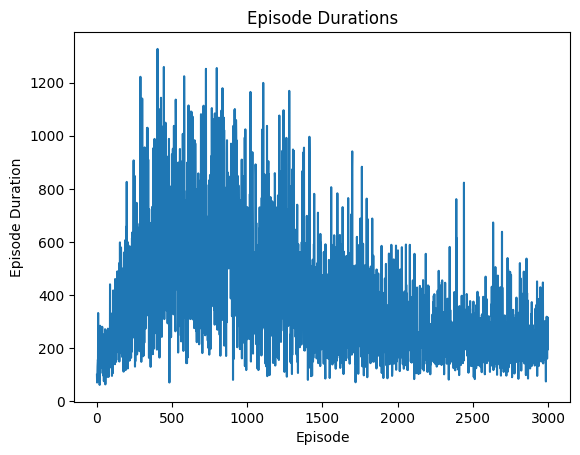

In [26]:
plt.plot(episode_durations, label='test')
plt.xlabel('Episode')
plt.ylabel('Episode Duration')
plt.title('Episode Durations')
plt.show()

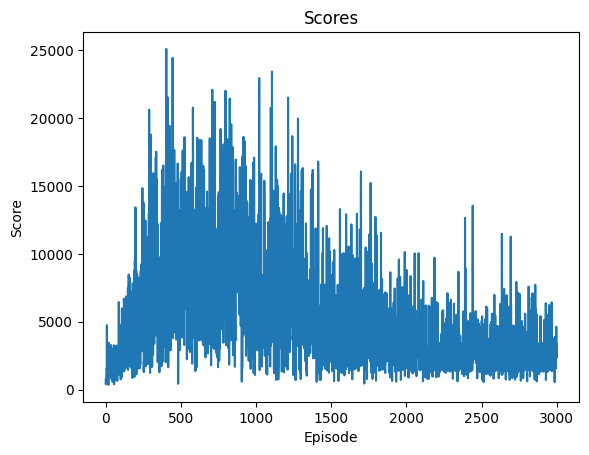

In [27]:
plt.plot(scores, label='test')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('Scores')
plt.show()

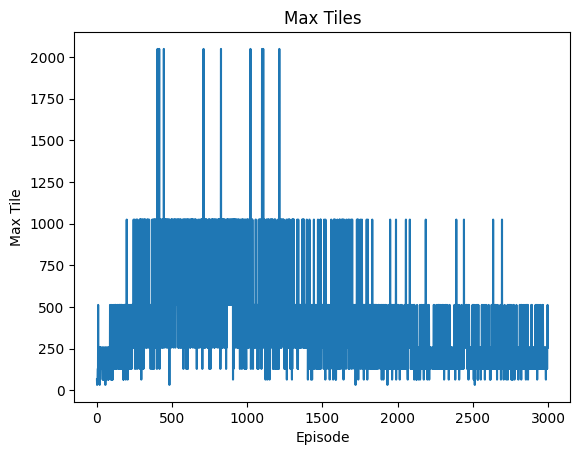

In [28]:
plt.plot(max_tiles, label='test')
plt.xlabel('Episode')
plt.ylabel('Max Tile')
plt.title('Max Tiles')
plt.show()